# 01 · Replicação do modelo MQO

Reproduz, a partir dos dados trimestrais de 2000 a 2021, as duas regressões do artigo:

- **Quadro 3** — MQO com as variáveis em nível;
- **Quadro 4** — MQO após a correção de autocorrelação (CORC), com $\hat\rho$ obtido do Durbin-Watson.

O código segue o apêndice do artigo, com três ajustes que não alteram nenhum resultado: caminho relativo para os dados, `dropna()` chamado corretamente e figuras gravadas em `output/`.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from statsmodels.stats.stattools import durbin_watson

pd.set_option("display.precision", 4)
FIG = "../output/figures/"
TAB = "../output/tables/"

## Dados

| Variável | Descrição | Fonte |
|---|---|---|
| `quantumexp` (Y) | Índice de quantum das exportações | SECEX / Ministério da Economia |
| `preço_basico` (X1) | Índice de preço das exportações de produtos básicos | SECEX / Ministério da Economia |
| `cambio_efetivo` (X2) | Taxa de câmbio efetiva real, deflacionada pelo INPC | IPEADATA |
| `PIB_China` (X3) | Índice do PIB trimestral da China | National Bureau of Statistics of China |

As séries mensais foram somadas por trimestre. O índice `serie` indica ano e trimestre (20001 = 1º trimestre de 2000).

In [2]:
dados = pd.read_csv("../data/exportacoes_trimestral.csv", index_col="serie")
dados.describe().T

,count,mean,std,min,25%,50%,75%,max
quantumexp,88.0,298.9887,68.9769,143.5159,262.0023,310.6480,339.1780,452.5618
preço_basico,88.0,361.0590,103.4785,201.7646,270.3623,369.5088,428.2264,561.5372
cambio_efetivo,88.0,418.3706,93.0888,278.4784,349.4377,392.8034,482.3465,688.8554
PIB_China,88.0,103.5611,11.4249,74.1497,99.6961,108.3081,111.7298,121.0007


## Correlações (Gráfico 8 do artigo)

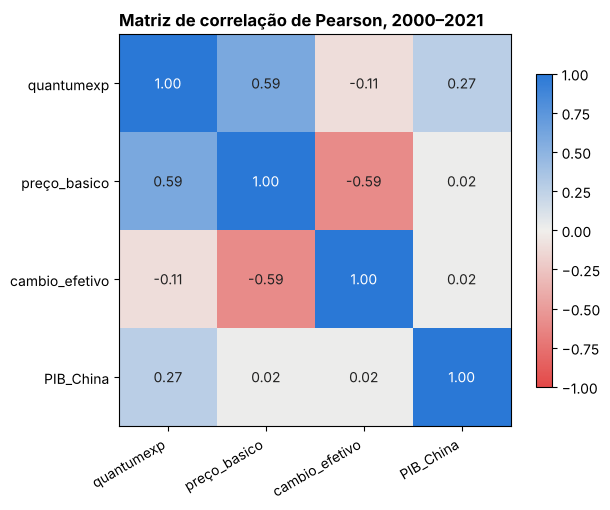

In [3]:
corr = dados.corr()

cmap = LinearSegmentedColormap.from_list("div", ["#e34948", "#f0efec", "#2a78d6"])
fig, ax = plt.subplots(figsize=(6.5, 5.2))
im = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=30, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=10,
                color="white" if abs(corr.iloc[i, j]) > 0.6 else "#222")
ax.set_title("Matriz de correlação de Pearson, 2000–2021", loc="left", fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
fig.savefig(FIG + "correlacoes.png", dpi=200, bbox_inches="tight")
plt.show()

## Modelo 1 · MQO em nível (Quadro 3)

$$Y_t = \beta_0 + \beta_1 X_{1t} + \beta_2 X_{2t} + \beta_3 X_{3t} + e_t$$

In [4]:
X = dados[["preço_basico", "cambio_efetivo", "PIB_China"]]
Y = dados[["quantumexp"]]

modelo_mqo = sm.OLS(Y, sm.add_constant(X)).fit()
print(modelo_mqo.summary())

                            OLS Regression Results                            
Dep. Variable:             quantumexp   R-squared:                       0.496
Model:                            OLS   Adj. R-squared:                  0.478
Method:                 Least Squares   F-statistic:                     27.52
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           1.72e-12
Time:                        22:57:09   Log-Likelihood:                -466.82
No. Observations:                  88   AIC:                             941.6
Df Residuals:                      84   BIC:                             951.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           -158.6294     66.710     -2.

O Durbin-Watson de 0,307 indica forte autocorrelação positiva dos resíduos: com erros autocorrelacionados, os erros-padrão do MQO ficam subestimados e os testes *t* perdem validade.

## Modelo 2 · Correção de autocorrelação (Quadro 4)

Estima-se $\hat\rho = 1 - DW/2$ e aplica-se a quase-diferença a todas as variáveis:

$$Y_t - \hat\rho Y_{t-1} = \beta_0(1-\hat\rho) + \beta_1 (X_{1t} - \hat\rho X_{1,t-1}) + \dots + u_t$$

A primeira observação se perde na transformação (87 trimestres).

In [5]:
dw = durbin_watson(modelo_mqo.resid)
rho = 1 - round(dw, 3) / 2          # o artigo usa o DW arredondado (0,307)
print(f"Durbin-Watson: {dw:.3f}   rho estimado: {rho:.4f}")

Y1 = (Y - rho * Y.shift(1)).dropna()
X1 = (X - rho * X.shift(1)).dropna()

modelo_corc = sm.OLS(Y1, sm.add_constant(X1)).fit()
print(modelo_corc.summary())

Durbin-Watson: 0.307   rho estimado: 0.8465
                            OLS Regression Results                            
Dep. Variable:             quantumexp   R-squared:                       0.479
Model:                            OLS   Adj. R-squared:                  0.460
Method:                 Least Squares   F-statistic:                     25.40
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           9.39e-12
Time:                        22:57:09   Log-Likelihood:                -402.34
No. Observations:                  87   AIC:                             812.7
Df Residuals:                      83   BIC:                             822.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------


## Conferência com o artigo

Os coeficientes, erros-padrão e estatísticas abaixo devem coincidir com os Quadros 3 e 4 publicados.

In [6]:
def resumo(m, nome):
    t = pd.DataFrame({
        "coef": m.params, "erro_padrao": m.bse, "t": m.tvalues, "p_valor": m.pvalues,
        "ic95_inf": m.conf_int()[0], "ic95_sup": m.conf_int()[1],
    })
    t.insert(0, "modelo", nome)
    return t

tabela = pd.concat([resumo(modelo_mqo, "MQO em nível"), resumo(modelo_corc, "MQO corrigido (CORC)")])
tabela.round(4).to_csv(TAB + "coeficientes.csv", index_label="variavel")

estatisticas = pd.DataFrame({
    "R2": [modelo_mqo.rsquared, modelo_corc.rsquared],
    "F": [modelo_mqo.fvalue, modelo_corc.fvalue],
    "Durbin_Watson": [durbin_watson(modelo_mqo.resid), durbin_watson(modelo_corc.resid)],
    "n": [int(modelo_mqo.nobs), int(modelo_corc.nobs)],
}, index=["MQO em nível", "MQO corrigido (CORC)"])
estatisticas.round(3).to_csv(TAB + "estatisticas.csv")

# Valores publicados no artigo
publicado = {
    "MQO em nível":         {"preço_basico": 0.5322, "cambio_efetivo": 0.2685, "PIB_China": 1.4786},
    "MQO corrigido (CORC)": {"preço_basico": 0.3439, "cambio_efetivo": 0.0690, "PIB_China": 1.2042},
}
for m, nome in [(modelo_mqo, "MQO em nível"), (modelo_corc, "MQO corrigido (CORC)")]:
    for v, valor in publicado[nome].items():
        assert round(m.params[v], 4) == valor, (nome, v)
print("Coeficientes idênticos aos publicados nos Quadros 3 e 4.")
display(tabela.round(4))
display(estatisticas.round(3))

Coeficientes idênticos aos publicados nos Quadros 3 e 4.


,modelo,coef,erro_padrao,t,p_valor,ic95_inf,ic95_sup
const,MQO em nível,-158.6294,66.7101,-2.3779,0.0197,-291.2898,-25.9691
preço_basico,MQO em nível,0.5322,0.0643,8.2757,0.0000,0.4043,0.6600
cambio_efetivo,MQO em nível,0.2685,0.0715,3.7570,0.0003,0.1264,0.4107
PIB_China,MQO em nível,1.4786,0.4682,3.1580,0.0022,0.5475,2.4097
const,MQO corrigido (CORC),4.3505,11.3909,0.3819,0.7035,-18.3055,27.0065
preço_basico,MQO corrigido (CORC),0.3439,0.1239,2.7762,0.0068,0.0975,0.5903
cambio_efetivo,MQO corrigido (CORC),0.0690,0.0923,0.7469,0.4572,-0.1147,0.2526
PIB_China,MQO corrigido (CORC),1.2042,0.1501,8.0205,0.0000,0.9056,1.5028


,R2,F,Durbin_Watson,n
MQO em nível,0.496,27.518,0.307,88
MQO corrigido (CORC),0.479,25.399,2.301,87


## Comparação dos coeficientes

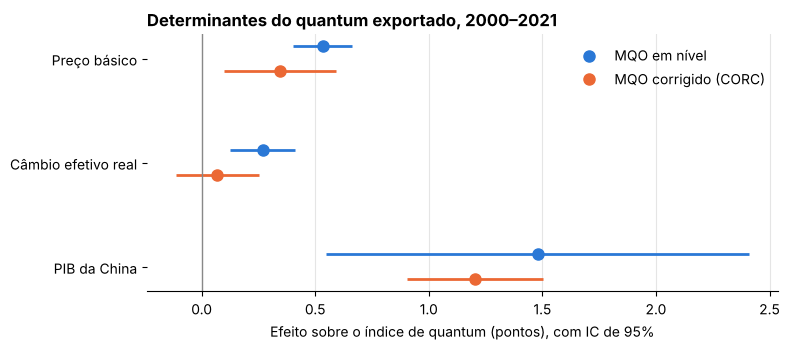

In [7]:
vars_ = ["preço_basico", "cambio_efetivo", "PIB_China"]
rotulos = {"preço_basico": "Preço básico", "cambio_efetivo": "Câmbio efetivo real", "PIB_China": "PIB da China"}
modelos = [(modelo_mqo, "MQO em nível", "#2a78d6", -0.12), (modelo_corc, "MQO corrigido (CORC)", "#eb6834", 0.12)]

fig, ax = plt.subplots(figsize=(8, 3.6))
for m, nome, cor, desloc in modelos:
    ic = m.conf_int().loc[vars_]
    y = np.arange(len(vars_)) + desloc
    ax.hlines(y, ic[0], ic[1], color=cor, linewidth=2)
    ax.plot(m.params[vars_], y, "o", color=cor, markersize=8, label=nome)
ax.axvline(0, color="#888", linewidth=1)
ax.set_yticks(range(len(vars_)), [rotulos[v] for v in vars_])
ax.invert_yaxis()
ax.set_xlabel("Efeito sobre o índice de quantum (pontos), com IC de 95%")
ax.set_title("Determinantes do quantum exportado, 2000–2021", loc="left", fontweight="bold")
ax.legend(frameon=False, loc="upper right")
ax.grid(axis="x", color="#e5e5e5")
ax.spines[["top", "right", "left"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG + "coeficientes.png", dpi=200, bbox_inches="tight")
plt.show()

## Diagnóstico dos resíduos (Quadros 5 a 7)

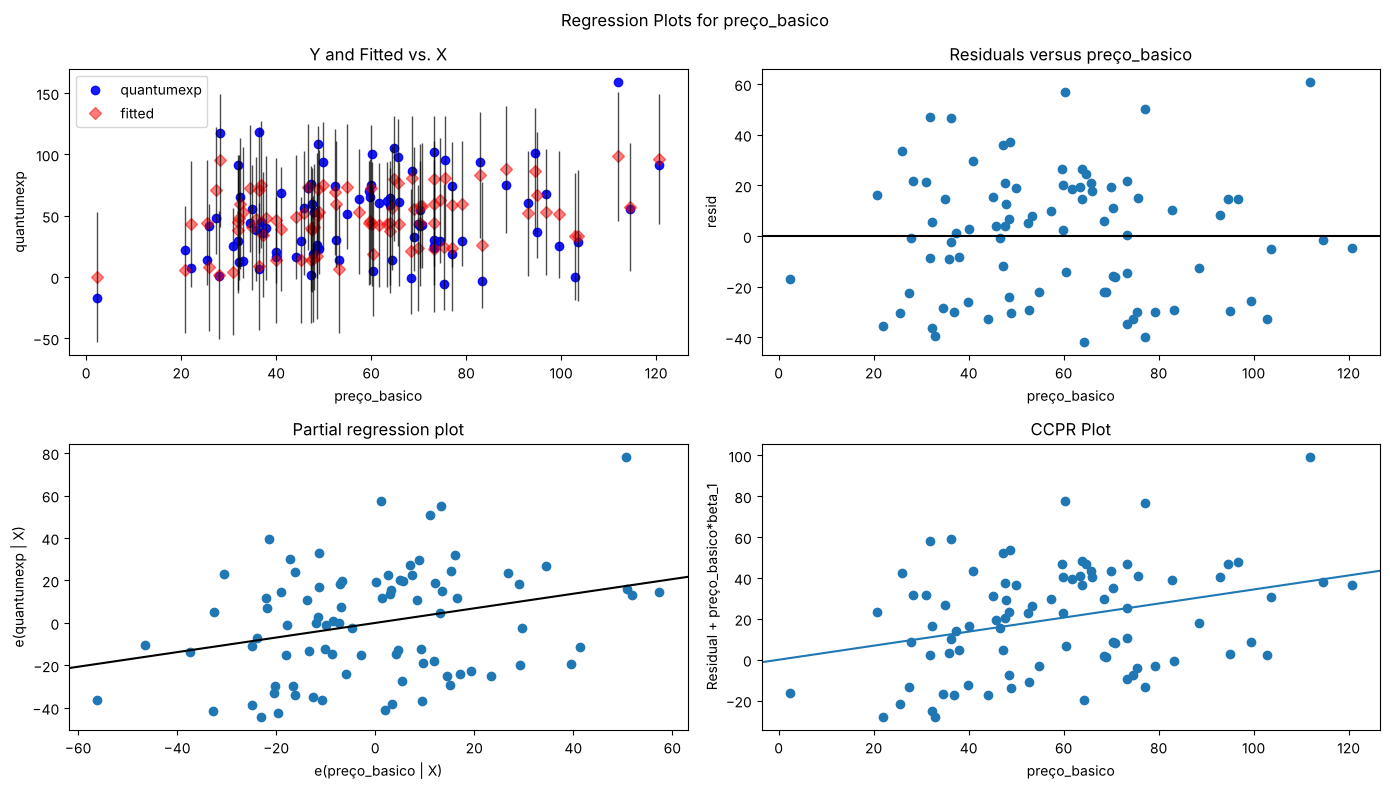

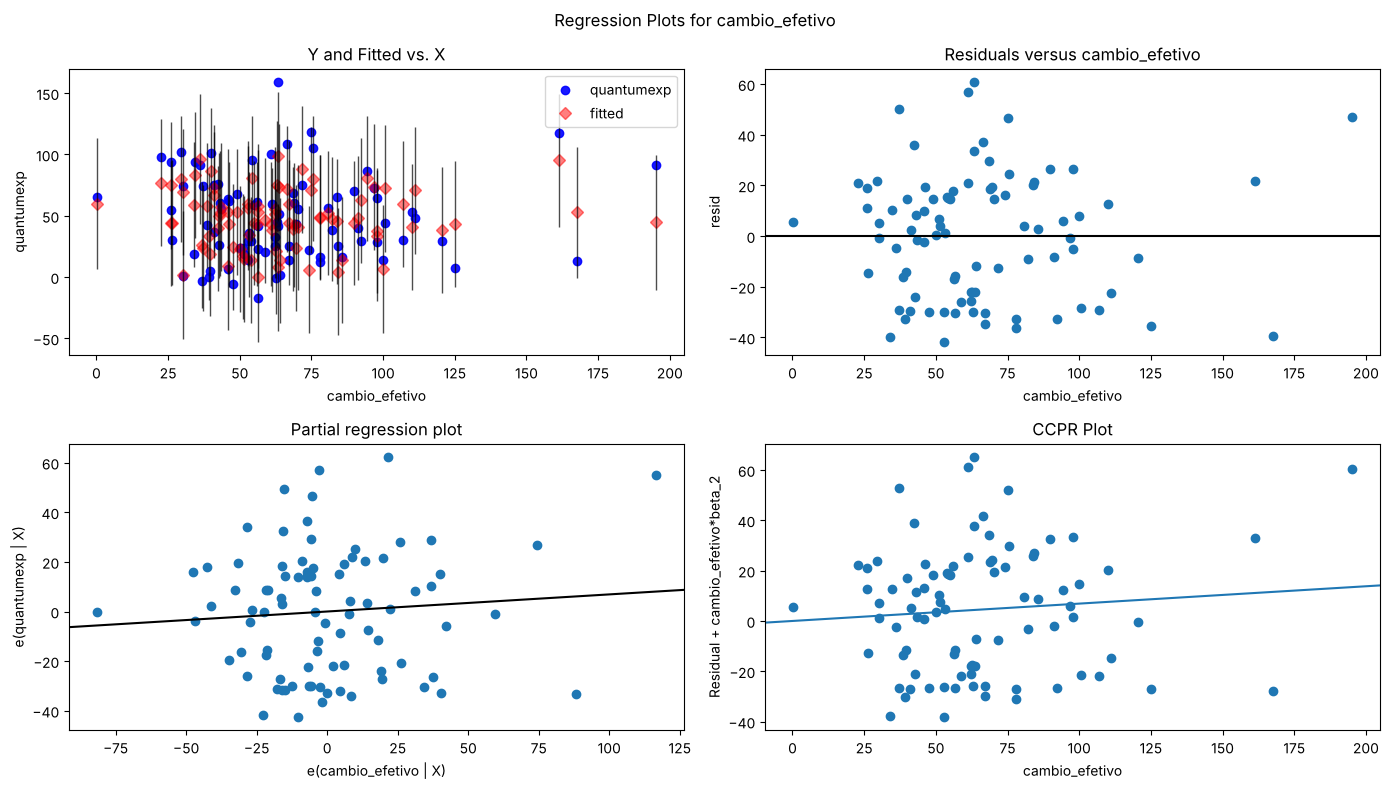

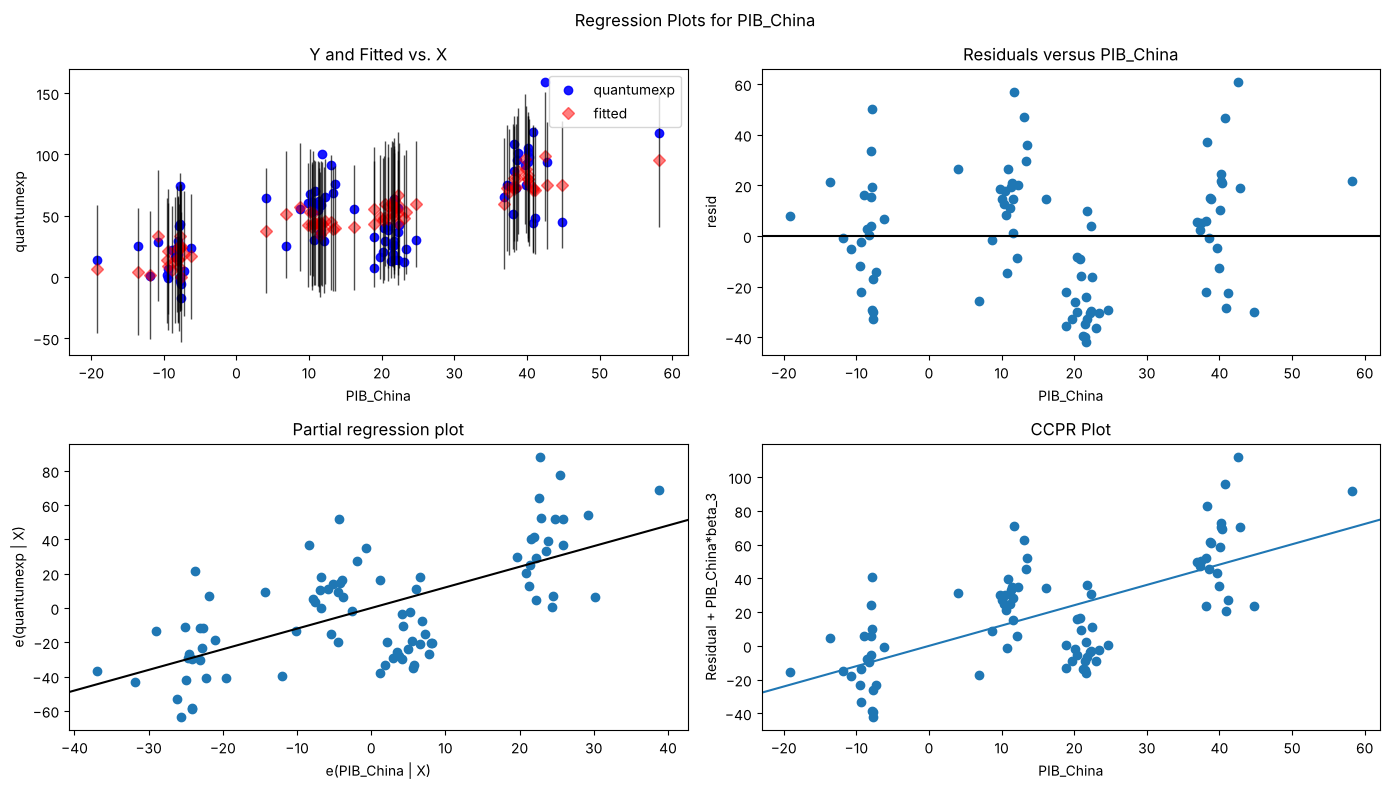

In [8]:
for v in vars_:
    fig = plt.figure(figsize=(14, 8))
    sm.graphics.plot_regress_exog(modelo_corc, v, fig=fig)
    fig.tight_layout()
    fig.savefig(FIG + f"residuos_{v.replace('ç', 'c')}.png", dpi=150, bbox_inches="tight")
    plt.show()